In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Score range
MIN_SCORE = 150
MAX_SCORE = 700
RANGE = MAX_SCORE - MIN_SCORE

# Tunable parameters
K = 2.5   # steepness
M = 3.8   # midpoint
P = 2.0   # hard-top power

def curved_score(avg_rating, k=K, m=M, p=P):
    """Compute the curved score from avg rating."""
    S = 1.0 / (1.0 + math.exp(-k * (avg_rating - m)))  # logistic
    curved = S ** p  # hard-top
    return MIN_SCORE + RANGE * curved

def exponential_score(avg_rating, p=P):
    # avg_rating is between 1 and 5
    normalized = (avg_rating - 1) / 4  # scale to 0-1
    curved = normalized ** p  # adjust power for curve
    final = MIN_SCORE + (curved * RANGE)
    return round(final)

def linear_score(avg_rating):
    # avg_rating is between 1 and 5
    normalized = (avg_rating - 1) / 4  # scale to 0-1
    final = MIN_SCORE + (normalized * RANGE)
    return round(final)

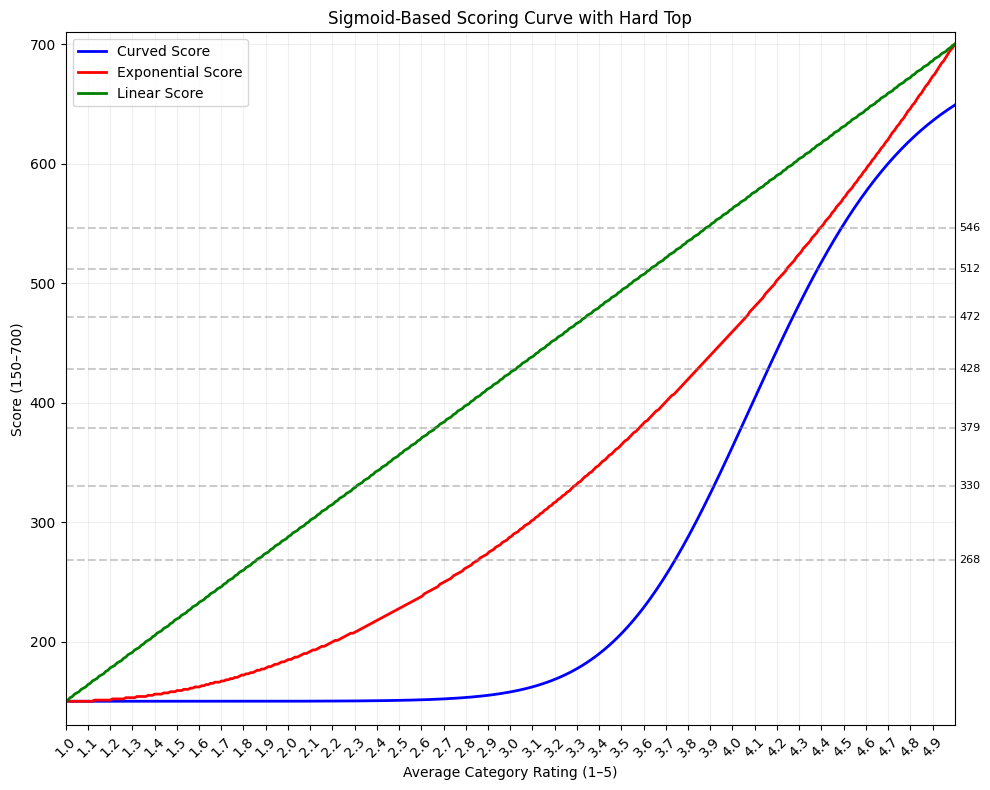

In [7]:
# --- Generate data for the plot ---
x = np.linspace(1.0, 5.0, 400)  # avg ratings from 1 to 5
y = [curved_score(val) for val in x]
y1 = [exponential_score(val) for val in x]
y2 = [linear_score(val) for val in x]

# Plot curve
plt.figure(figsize=(10, 8))
plt.plot(x, y, label="Curved Score", color="blue", linewidth=2)
plt.plot(x, y1, label="Exponential Score", color="red", linewidth=2)
plt.plot(x, y2, label="Linear Score", color="green", linewidth=2)

# Add horizontal bands (example NCLC-like thresholds)
thresholds = [268, 330, 379, 428, 472, 512, 546]
colors = ['#e6f2ff'] * len(thresholds)

for t in thresholds:
    plt.axhline(t, color='gray', linestyle='--', alpha=0.4)
    plt.text(5.02, t, f'{t}', va='center', fontsize=8)

# Axis labels
plt.title("Sigmoid-Based Scoring Curve with Hard Top")
plt.xlabel("Average Category Rating (1–5)")
plt.ylabel(f"Score ({MIN_SCORE}–{MAX_SCORE})")
plt.ylim(MIN_SCORE-20, MAX_SCORE + 10)
plt.xlim(1, 5)
plt.xticks(np.arange(1, 5, 0.1), rotation=45)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()

plt.show()